In [1]:
#TODO coil100 did i test wether to use border, wrap or zeroing out new region for search?

In [2]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from its.search import InverseTransformationSearch
from search.parallel_gradient import ParallelGradientDescent
from utils.affine_transforms_old import AffineTransformation2D
from utils.sampling import BatchNegativeSampler

#torch.cuda.is_available = lambda: False
#device = torch.device("cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#look for experiment files in parents
import os

path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)

experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")
dataset = "coil100"

default_architecutre_mapping = {
    "mnist":"resnet_small",
    "bigger_mnist":"resnet_small",
    "emnist": "extended_resnet_small",
    "bigger_emnist":"bigger_extended_resnet_small",
    "coil100":"coil_resnet_small",
    "tu_berlin":"bi_lstm",
    "modelnet10":"pointnetplus",
}



architecture = default_architecutre_mapping[dataset]
budget = None

In [3]:
from utils.transforms.apply import grid_resample_border,grid_resample_reflection

In [4]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)

dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data, batch_size=dataset_info.batch_size)
transform_name = dataset_info.transform_seq_name

In [5]:


dataset_dict.keys()
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']

In [6]:
x=next(iter(test_loader_transformed))[0]

In [7]:
batch_size = next(iter(train_loader))[0].shape[0]


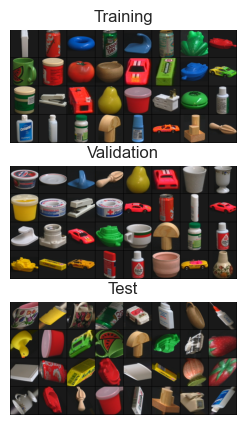

In [8]:
from utils.eval.vis import vis_dataset

vis_dataset(train_loader,val_loader,test_loader_transformed)

In [9]:
from experiment_thesis.main import train_and_get_model,train_or_load_energy_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model

model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
# Add results dir and helper for save paths
results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture, "comparision_over_budget")
os.makedirs(results_dir_path, exist_ok=True)


def savepath(label: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path,transform_name, f"{safe}.json")

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\coil100_coil_resnet_small.safetensors


(FlexibleResNet(
   (stem_conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
   (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (stem_act): GELU(approximate='none')
   (stages): ModuleList(
     (0): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (act): GELU(approximate='none')
       )
     )
     (1): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

In [11]:
model.eval().to(device)

FlexibleResNet(
  (stem_conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [12]:
res = evaluate_base_model(model, test_loader_transformed, device)
print(res)

{'accuracy': 0.8194444179534912, 'f2_macro': 0.8234886527061462, 'f2_micro': 0.8194444179534912, 'f2_weighted': 0.8131706714630127}


In [13]:
res = evaluate_base_model(model, test_loader, device)
print(res)

{'accuracy': 1.0, 'f2_macro': 1.0, 'f2_micro': 1.0, 'f2_weighted': 1.0}


In [14]:
class TensorGeometricModelUnwrapper(torch.nn.Module):
    """
    Wrapper for a torch_geometric model that receives a tuple of (pos, y) as input and creates
    a Data object from it that is passed to the model.
    """
    def __init__(self):
        super(TensorGeometricModelUnwrapper, self).__init__()

    def forward(self, data):
        # pos and y are batched tensors from a DataLoader
        # need to reconstruct the original Data objects for torch_geometric models

        pos = data.pos
        batch = data.batch
        #split pos into individual tensors based on batch
        pos_list = torch.split(pos, torch.bincount(batch).tolist())
        return torch.stack(pos_list)

In [15]:
#chek if data is iamge data
is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]

In [16]:
from utils.transforms.apply import grid_resample
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images

transform_seq = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method,
    init_method="sobol"
    ).to(device)

In [17]:
from experiment_thesis.dataset_preperation.basic_networks import get_network_layer

layer,layer_io = get_network_layer(dataset_info, architecture, 0, num_classes=None, num_rotations=8)

In [18]:
from confidence.direct.logit_based import EnergyConfidence
from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence

logit_energy = SinglePassConfidence(model, EnergyConfidence(), index=None)
problem_energy_logits = TransformationProblem(logit_energy, transform_seq,                                              consolidate_method="consolidate_simple")
#test ot
from search.shgo import SHGO
random_search = SHGO(initial_samples=120, local_max_steps=0)

from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search, evaluate_confidence_and_search, \
    ITSWRAPPER


In [19]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_energy_logits,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("energy_confidence_transformed"), show_progress=True,
    repeats=1)

{'repeats': 1,
 'accuracy_mean': 0.9347222447395325,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.9374155402183533,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.9347222447395325,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.9309128522872925,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.9347222447395325,
   'f2_macro': 0.9374155402183533,
   'f2_micro': 0.9347222447395325,
   'f2_weighted': 0.9309128522872925}]}

In [20]:
model.to(device).eval()

FlexibleResNet(
  (stem_conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [21]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [22]:
from utils.augments import ComposeAugmentations, random_gaussian_noise, random_contrast, \
    random_gamma  ,random_blur_or_sharpen,build_default_augmentations
import utils.augments

def dec_strat(x, idd, y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    #convert to tensor where y>=0 if correct, y<0 if incorrect
    y = torch.where(eq, y_true, -1)
    return y


from utils.augments import build_default_augmentations, small_affine_augment_2d
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import importlib
import utils.sampling_strategy
import utils.sampling

importlib.reload(utils.sampling)
from utils.sampling import BatchNegativeSampler


energy_model2 = get_network(dataset_info,architecture, num_classes=1).to(device)

from experiment_thesis.main import train_or_load_energy_model

if is_image_data:
    transform_true_function = small_affine_augment_2d
    affine_augment = utils.augments.build_default_augmentations()
else:
    transform_true_function = None
    affine_augment = None

negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =transform_true_function, augment_function=affine_augment,
    decision_strategy=dec_strat,
)

energy_conf2 = train_or_load_energy_model(
    energy_model2, model_dir_path, f"{modelname}_energy2", train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    }, negative_sampling_module=negative_sampling_module, load_if_exists=True)


Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\coil100_coil_resnet_small_energy2_energy_conf_best.safetensors


In [23]:
from utils.augments import ComposeAugmentations, random_gaussian_noise, random_contrast, \
    random_gamma  ,random_blur_or_sharpen,build_default_augmentations
import utils.augments

def dec_strat(x, idd, y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    #convert to tensor where y>=0 if correct, y<0 if incorrect
    y = torch.where(eq, y_true, -1)
    return y


from utils.augments import build_default_augmentations, small_affine_augment_2d
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import importlib
import utils.sampling_strategy
import utils.sampling

importlib.reload(utils.sampling)
from utils.sampling import BatchNegativeSampler


energy_model3 = get_network(dataset_info,architecture, num_classes=1).to(device)

from experiment_thesis.main import train_or_load_energy_model

if is_image_data:
    transform_true_function = small_affine_augment_2d
    affine_augment = utils.augments.build_default_augmentations()
else:
    transform_true_function = None
    affine_augment = None
from utils.transforms.apply import grid_resample_reflection
transform_seq_reflect =  get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method= grid_resample_reflection,
    init_method="sobol"
).to(device)

negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq_reflect, ), transform_true_function
    =transform_true_function, augment_function=affine_augment,
    decision_strategy=dec_strat,
)

energy_conf3 = train_or_load_energy_model(
    energy_model3, model_dir_path, f"{modelname}_energy3", train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    }, negative_sampling_module=negative_sampling_module, load_if_exists=True)


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4070') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:654: Checkpoint directory C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                     | Type                 | Params | Mode 
--------------------------------------------------------------------------
0 | negative_sampling_

Epoch 0: 100%|██████████| 180/180 [00:14<00:00, 12.49it/s, v_num=145, train_loss_step=0.399, val_acc=0.769, val_loss=0.501, train_loss_epoch=0.477]

Epoch 0, global step 180: 'val_acc' reached 0.76944 (best 0.76944), saving model to 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\models\\checkpoints\\coil100_coil_resnet_small_energy3_energy_conf_best.ckpt' as top 1


Epoch 1: 100%|██████████| 180/180 [00:14<00:00, 12.17it/s, v_num=145, train_loss_step=0.297, val_acc=0.778, val_loss=0.470, train_loss_epoch=0.427]

Epoch 1, global step 360: 'val_acc' reached 0.77778 (best 0.77778), saving model to 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\models\\checkpoints\\coil100_coil_resnet_small_energy3_energy_conf_best.ckpt' as top 1


...

Epoch 48: 100%|██████████| 180/180 [00:08<00:00, 22.22it/s, v_num=145, train_loss_step=0.395, val_acc=0.869, val_loss=0.296, train_loss_epoch=0.303]

Epoch 48, global step 8820: 'val_acc' was not in top 1


Epoch 49: 100%|██████████| 180/180 [00:08<00:00, 21.75it/s, v_num=145, train_loss_step=0.194, val_acc=0.865, val_loss=0.302, train_loss_epoch=0.298]

Epoch 49, global step 9000: 'val_acc' was not in top 1
`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 180/180 [00:08<00:00, 21.74it/s, v_num=145, train_loss_step=0.194, val_acc=0.865, val_loss=0.302, train_loss_epoch=0.298]
Best Lightning checkpoint: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\checkpoints\coil100_coil_resnet_small_energy3_energy_conf_best.ckpt
Best model weights saved to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\coil100_coil_resnet_small_energy3_energy_conf_best.safetensors


In [24]:
model.to(device).eval()

FlexibleResNet(
  (stem_conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [25]:
from model.pointnet_plus import SAModule
def set_deterministic_fps(model, random_start=False):
    for module in model.modules():
        if isinstance(module, SAModule):
            module.random_start = random_start
            print(f"Set random_start={random_start} for {module.__class__.__name__}")

set_deterministic_fps(model)
set_deterministic_fps(energy_model2)

In [39]:
energy_conf2.to(device).eval()



problem_energy2 = TransformationProblem(energy_conf2, transform_seq,                                              consolidate_method="consolidate_simple")

problem_energy3 = TransformationProblem(energy_conf3, transform_seq_reflect,                                              consolidate_method="consolidate_simple")

problem_energy4 = TransformationProblem(energy_conf3, transform_seq,                                              consolidate_method="consolidate_simple")

In [27]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_energy2,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_confidence_transformed"), show_progress=True,
    repeats=1)

{'repeats': 1,
 'accuracy_mean': 0.9541666507720947,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.9558418393135071,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.9541666507720947,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.9527705311775208,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.9541666507720947,
   'f2_macro': 0.9558418393135071,
   'f2_micro': 0.9541666507720947,
   'f2_weighted': 0.9527705311775208}]}

In [28]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_energy3,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_confidence_transformed_reflect"), show_progress=True,
    repeats=1)

{'repeats': 1,
 'accuracy_mean': 0.9194444417953491,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.9176013469696045,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.9194444417953491,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.9165730476379395,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.9194444417953491,
   'f2_macro': 0.9176013469696045,
   'f2_micro': 0.9194444417953491,
   'f2_weighted': 0.9165730476379395,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None}]}

In [40]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_energy4,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_confidence_transformed_reflect2"), show_progress=True,
    repeats=1)

{'repeats': 1,
 'accuracy_mean': 0.9305555820465088,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.9256254434585571,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.9305555820465088,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.9287401437759399,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.9305555820465088,
   'f2_macro': 0.9256254434585571,
   'f2_micro': 0.9305555820465088,
   'f2_weighted': 0.9287401437759399,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None}]}

In [29]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [30]:
from torch.utils.data import SequentialSampler
from embedding_cache import LayerEmbeddingCache



cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train"

cache_train = LayerEmbeddingCache(model, train_loader_no_shuffle,
                                  cache_dir=os.path.join(embedding_cache_path, cache_name_train))

dual_output_model = cache_train.make_wrapper(layer, capture_modes=layer_io, concat=False, flatten=True)
embeddings_t, final_t, classes_t = cache_train.__call__(layer, capture_modes=layer_io, flatten=True)




from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence, PerClassKNNConfidence

from confidence.input_transform import InputTransformImage, PCAInputModule, RandomProjectionModule

nn_pytorch_pretrained = PerClassKNNConfidence(metric="cosine", input_transform=None,computation_mode="masked",k=1)
nn_pytorch_pretrained.fit(embeddings_t, classes_t)
nn_pytorch_pretrained.to(device)

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained, EnergyConfidence(), mult=False, b=0.0)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_nn_pytorch_pretrained = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq,
                                                      consolidate_method="consolidate_simple")
model.eval().to(device)

FlexibleResNet(
  (stem_conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [31]:
print(problem_nn_pytorch_pretrained.transform_sequence.application_method)

<function grid_resample_border at 0x00000295B9572710>


In [32]:
#benchmark model and dual output model

In [33]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_nn_pytorch_pretrained,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("knn_per_class_confidence_transformed"), show_progress=True,
    repeats=4,overwrite=False)

{'repeats': 4,
 'accuracy_mean': 0.9916666746139526,
 'accuracy_std': 0.00494310213252902,
 'accuracy_se': 0.00247155106626451,
 'f2_macro_mean': 0.9916228652000427,
 'f2_macro_std': 0.0049704681150615215,
 'f2_macro_se': 0.0024852340575307608,
 'f2_micro_mean': 0.9916666746139526,
 'f2_micro_std': 0.00494310213252902,
 'f2_micro_se': 0.00247155106626451,
 'f2_weighted_mean': 0.9914653897285461,
 'f2_weighted_std': 0.005047768820077181,
 'f2_weighted_se': 0.0025238844100385904,
 'per_run': [{'accuracy': 0.9847221970558167,
   'f2_macro': 0.9845240116119385,
   'f2_micro': 0.9847221970558167,
   'f2_weighted': 0.9843823909759521},
  {'accuracy': 0.9958333373069763,
   'f2_macro': 0.9957007765769958,
   'f2_micro': 0.9958333373069763,
   'f2_weighted': 0.9957538843154907,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.9916666746139526,
   'f2_macro': 0.992

In [34]:
from utils.transforms.apply import grid_resample,grid_resample_deblur,grid_resample_reflection
problem_nn_pytorch_pretrained.transform_sequence.application_method =  grid_resample

In [35]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_nn_pytorch_pretrained,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("knn_per_class_confidence_transformed_zero_fill"), show_progress=True,
    repeats=4,overwrite=False)

{'repeats': 4,
 'accuracy_mean': 0.9739583730697632,
 'accuracy_std': 0.001747642527334392,
 'accuracy_se': 0.000873821263667196,
 'f2_macro_mean': 0.9759862422943115,
 'f2_macro_std': 0.0014767954126000404,
 'f2_macro_se': 0.0007383977063000202,
 'f2_micro_mean': 0.9739583730697632,
 'f2_micro_std': 0.001747642527334392,
 'f2_micro_se': 0.000873821263667196,
 'f2_weighted_mean': 0.9732228517532349,
 'f2_weighted_std': 0.0018724474357441068,
 'f2_weighted_se': 0.0009362237178720534,
 'per_run': [{'accuracy': 0.9736111164093018,
   'f2_macro': 0.9759191274642944,
   'f2_micro': 0.9736111164093018,
   'f2_weighted': 0.9728386998176575,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.9736111164093018,
   'f2_macro': 0.9754335880279541,
   'f2_micro': 0.9736111164093018,
   'f2_weighted': 0.9726158976554871,
   'per_sample_errors': None,
   'per_sample_matric

In [36]:
problem_nn_pytorch_pretrained.transform_sequence.application_method =  grid_resample_deblur
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_nn_pytorch_pretrained,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("knn_per_class_confidence_transformed_deblur"), show_progress=True,
    repeats=4,overwrite=False)


{'repeats': 4,
 'accuracy_mean': 0.972569465637207,
 'accuracy_std': 0.0006944537162780762,
 'accuracy_se': 0.0003472268581390381,
 'f2_macro_mean': 0.9750526547431946,
 'f2_macro_std': 0.0005506754969246686,
 'f2_macro_se': 0.0002753377484623343,
 'f2_micro_mean': 0.972569465637207,
 'f2_micro_std': 0.0006944537162780762,
 'f2_micro_se': 0.0003472268581390381,
 'f2_weighted_mean': 0.9718114733695984,
 'f2_weighted_std': 0.0007661174749955535,
 'f2_weighted_se': 0.00038305873749777675,
 'per_run': [{'accuracy': 0.9722222089767456,
   'f2_macro': 0.9749772548675537,
   'f2_micro': 0.9722222089767456,
   'f2_weighted': 0.9713994264602661,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.9722222089767456,
   'f2_macro': 0.974899411201477,
   'f2_micro': 0.9722222089767456,
   'f2_weighted': 0.9712702631950378,
   'per_sample_errors': None,
   'per_sample_matr

In [37]:
problem_nn_pytorch_pretrained.transform_sequence.application_method =  grid_resample_reflection
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_nn_pytorch_pretrained,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("knn_per_class_confidence_transformed_reflected"), show_progress=True,
    repeats=4,overwrite=False)


{'repeats': 4,
 'accuracy_mean': 0.9920139312744141,
 'accuracy_std': 0.001747642527334392,
 'accuracy_se': 0.000873821263667196,
 'f2_macro_mean': 0.9924448728561401,
 'f2_macro_std': 0.0013989846920594573,
 'f2_macro_se': 0.0006994923460297287,
 'f2_micro_mean': 0.9920139312744141,
 'f2_micro_std': 0.001747642527334392,
 'f2_micro_se': 0.000873821263667196,
 'f2_weighted_mean': 0.9918512105941772,
 'f2_weighted_std': 0.0018094999250024557,
 'f2_weighted_se': 0.0009047499625012279,
 'per_run': [{'accuracy': 0.9944444298744202,
   'f2_macro': 0.9944082498550415,
   'f2_micro': 0.9944444298744202,
   'f2_weighted': 0.9943554997444153,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.9916666746139526,
   'f2_macro': 0.9923670887947083,
   'f2_micro': 0.9916666746139526,
   'f2_weighted': 0.9915361404418945,
   'per_sample_errors': None,
   'per_sample_matric

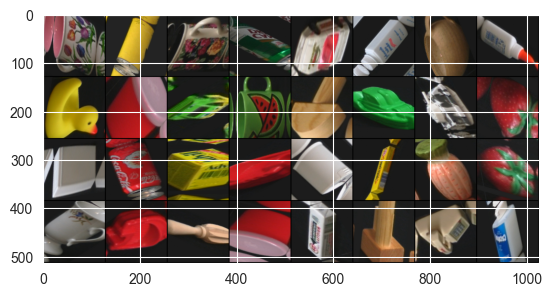

In [38]:
#transform random image using reflection
problem_nn_pytorch_pretrained.transform_sequence.application_method = grid_resample_reflection
x = next(iter(test_loader))[0].cuda()
p = problem_nn_pytorch_pretrained.transform_sequence.initial_param(x.shape[0]).cuda()
x_transformed = problem_nn_pytorch_pretrained.transform_sequence.transform(x,p)
plt.imshow(torchvision.utils.make_grid(x_transformed).cpu().permute(1,2,0))